# tICA dihedrals 3 state

In [72]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Prepare data

In [73]:
trajectories_labels = ["tica_dihedrals"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# timeseries of distances for contacts presents in pdb2f4k
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)


print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]



# ----------------------------
# static distances between residues in the reference structure (pdb2f4k)
# ----------------------------
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm
# ---------------------------------------

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


Estimate MSM

In [74]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj


name = trajectories_labels[0]

data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
dtraj = data["traj"].copy()
centers = data["centers"].copy()
C = tce.fit(dtraj).fetch_model()
submodel = C.submodel_largest(directed=True)
print(f"Submodel for {name} has {submodel.n_states} microstates.")
micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 100)
if np.any(dtrajs_dict[name] == -1):
    print(f"Warning: {name} has unassigned microstates after cleaning.")
msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
msm_dict[name] = msm

MSM lag time in frames: 250
Submodel for tica_dihedrals has 49 microstates.


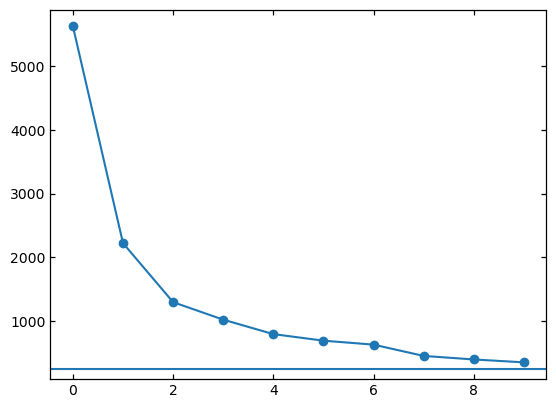

In [75]:
fig, ax = plt.subplots()
ax.plot(msm.timescales(10), marker='o')
ax.axhline(MSM_LAG_FRAMES)

Compute PCCA++ assignments of microstates

In [76]:
n_common = 5

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 3
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Populations

In [77]:
pcca.coarse_grained_stationary_probability

array([0.0577801 , 0.02656962, 0.19796496, 0.25993649, 0.45774883])

Compute all frame assignments (hard and soft)

In [78]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]

    # shape: n_frames x n_macrostates
    p_macro = memberships[dtraj, :]

    # hard macrostate assignment
    hard = np.argmax(p_macro, axis=1)

    pcca_probabilities_timeseries_dict[name] = p_macro
    hard_assignments_timeseries_dict[name] = hard

    print(name)
    print("p_macro shape:", p_macro.shape)
    print("hard shape:", hard.shape)
    print("macrostate counts:", np.bincount(hard))
    print()

tica_dihedrals
p_macro shape: (1526041, 5)
hard shape: (1526041,)
macrostate counts: [  5833  52074 428473 477498 562163]



---

## Structural Analysis - hard assignments

In [79]:
hard_assignments_timeseries_dict["tica_dihedrals"].shape

(1526041,)

### Helicity

In [80]:

# --------------------------------
# Helix dict (res idx 1,... 35)
# --------------------------------
helices = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

contact_names = np.loadtxt(
    data_folder + "hp35.crystaldists.ndx",
    delimiter=" ",
    dtype=int
)

print("Contact names shape:", contact_names.shape)

# Make sure contact_names is shaped as (n_contacts, 2)
if contact_names.ndim == 1:
    contact_names = contact_names.reshape(-1, 2)

contact_lookup = {i: tuple(contact_names[i]) for i in range(contact_names.shape[0])}

print("First contacts:")
for i in range(min(10, len(contact_lookup))):
    print(i, contact_lookup[i])


# --------------------------------
# Find contacts internal to helices
# --------------------------------

def find_contacts_within_region(contact_names, start, end):
    """
    Return indices of contacts whose two residues both lie in [start, end].

    Assumes contact_names has shape (n_contacts, 2), with residue numbering
    consistent with the helix definitions.
    """
    indices = []

    for k, (res_i, res_j) in enumerate(contact_names):
        if start <= res_i <= end and start <= res_j <= end:
            indices.append(k)

    return np.array(indices, dtype=int)


helix_contact_indices = {}

for helix_name, (start, end) in helices.items():
    idx = find_contacts_within_region(contact_names, start, end)
    helix_contact_indices[helix_name] = idx

    print(f"\n{helix_name}: residues {start}-{end}")
    print(f"Number of internal contacts: {len(idx)}")

    for k in idx:
        print(f"  column {k}: contact {tuple(contact_names[k])}")

Contact names shape: (53, 2)
First contacts:
0 (1, 5)
1 (1, 6)
2 (1, 9)
3 (1, 10)
4 (1, 14)
5 (1, 34)
6 (2, 6)
7 (3, 7)
8 (3, 14)
9 (4, 8)

H1: residues 3-10
Number of internal contacts: 4
  column 7: contact (3, 7)
  column 9: contact (4, 8)
  column 10: contact (5, 9)
  column 11: contact (6, 10)

H2: residues 14-19
Number of internal contacts: 2
  column 32: contact (14, 18)
  column 33: contact (15, 19)

H3: residues 22-32
Number of internal contacts: 7
  column 43: contact (22, 26)
  column 44: contact (23, 27)
  column 45: contact (24, 28)
  column 46: contact (25, 29)
  column 47: contact (26, 30)
  column 48: contact (27, 31)
  column 49: contact (28, 32)


Retrieve distances within helices in the pdb 

In [81]:
reference_distances = np.load(
    "../intermediate_outputs/closest_heavy_dist_map.npy"
) * 0.1  # Å to nm



helix_distances_reference = {}
for helix_name, idx in helix_contact_indices.items():
    start_idxs = [contact_names[k][0] for k in idx]
    print(f"{helix_name} start indices:", start_idxs)
    helix_distances_reference[helix_name] = [reference_distances[i-1, i + 3] for i in start_idxs] # starts from 0
    print(f"{helix_name} reference distances:", helix_distances_reference[helix_name])

H1 start indices: [3, 4, 5, 6]
H1 reference distances: [0.30382633209228516, 0.3010305881500244, 0.2969738721847534, 0.2920261383056641]
H2 start indices: [14, 15]
H2 reference distances: [0.3006548643112183, 0.3289121866226197]
H3 start indices: [22, 23, 24, 25, 26, 27, 28]
H3 reference distances: [0.29214413166046144, 0.2998203992843628, 0.2907871723175049, 0.30020458698272706, 0.3076613187789917, 0.29323320388793944, 0.29776792526245116]


Retrieve distances from samples

In [82]:
helix_distances = {
    helix_name: {}
    for helix_name in helix_contact_indices
}


for state in range(n_common):
    for helix_name, idx in helix_contact_indices.items():
        state_frames = hard_assignments_timeseries_dict["tica_dihedrals"] == state
        helix_distances[helix_name][state] = crystal_dist[state_frames][::100, idx]




def build_contact_distance_dataframe(
    helix_distances_dict,
    helix_contact_indices,
    contact_lookup,
    state_prefix="S"
):
    """
    Convert nested contact-distance data into long-format DataFrame.

    Expected structure
    ------------------
    helix_distances_dict[helix_name][state]
        -> array of shape (n_frames, n_contacts_in_helix)
    """
    rows = []

    for helix_name, state_dict in helix_distances_dict.items():
        contact_ids = np.asarray(
            helix_contact_indices[helix_name],
            dtype=int
        )

        for state, distances in state_dict.items():
            distances = np.asarray(distances)

            if distances.ndim != 2:
                raise ValueError(
                    f"Distances for {helix_name}, state {state} "
                    "must be two-dimensional."
                )

            if distances.shape[1] != len(contact_ids):
                raise ValueError(
                    f"Number of columns for {helix_name}, state {state} "
                    "does not match the number of contact IDs."
                )

            for local_i, contact_id in enumerate(contact_ids):
                start_res, end_res = contact_lookup[contact_id]
                values = distances[:, local_i]

                for value in values:
                    rows.append({
                        "Helix": helix_name,
                        "State": state,
                        "Basin": f"{state_prefix}{state}",
                        "Contact ID": contact_id,
                        "Start residue": start_res,
                        "End residue": end_res,
                        "Contact label": f"{start_res}-{end_res}",
                        "Distance": value,
                    })

    return pd.DataFrame(rows)


df_contacts = build_contact_distance_dataframe(
    helix_distances_dict=helix_distances,
    helix_contact_indices=helix_contact_indices,
    contact_lookup=contact_lookup,
)
display(df_contacts.head(10))

,Helix,State,Basin,Contact ID,Start residue,End residue,Contact label,Distance
0,H1,0,S0,7,3,7,3-7,0.72660
1,H1,0,S0,7,3,7,3-7,0.93061
2,H1,0,S0,7,3,7,3-7,0.78221
3,H1,0,S0,7,3,7,3-7,0.75550
4,H1,0,S0,7,3,7,3-7,0.90242
5,H1,0,S0,7,3,7,3-7,0.83287
6,H1,0,S0,7,3,7,3-7,0.90165
7,H1,0,S0,7,3,7,3-7,0.97414
8,H1,0,S0,7,3,7,3-7,0.35206
9,H1,0,S0,7,3,7,3-7,0.76223


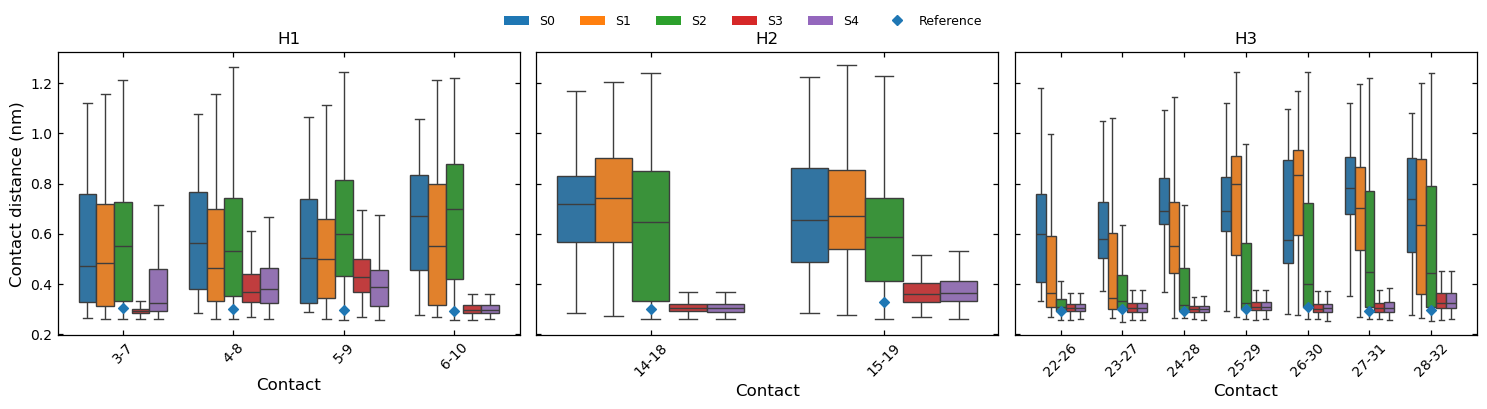

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Plot ordering
# ------------------------------------------------------------
helix_order = [
    helix_name
    for helix_name in helix_contact_indices
    if helix_name in df_contacts["Helix"].unique()
]

# Preserve the categorical order if Basin was already made categorical
if isinstance(df_contacts["Basin"].dtype, pd.CategoricalDtype):
    basin_order = [
        basin
        for basin in df_contacts["Basin"].cat.categories
        if basin in df_contacts["Basin"].dropna().unique()
    ]
else:
    basin_order = df_contacts["Basin"].drop_duplicates().tolist()

n_helices = len(helix_order)

if n_helices == 0:
    raise ValueError("No helices found in df_contacts.")

# ------------------------------------------------------------
# Create arbitrary number of panels
# ------------------------------------------------------------
fig, axs = plt.subplots(
    nrows=1,
    ncols=n_helices,
    figsize=(5 * n_helices, 4),
    sharey=True,
    squeeze=False
)

axs = axs.ravel()

# ------------------------------------------------------------
# Plot each helix
# ------------------------------------------------------------
for panel_i, (ax, helix_name) in enumerate(zip(axs, helix_order)):

    sub = (
        df_contacts.loc[df_contacts["Helix"] == helix_name]
        .copy()
    )

    # Use the order defined by helix_contact_indices rather than relying
    # on the order in which rows happen to occur in the dataframe.
    contact_order = []

    for contact_id in helix_contact_indices[helix_name]:
        start_res, end_res = contact_lookup[contact_id]
        contact_label = f"{start_res}-{end_res}"

        if contact_label in sub["Contact label"].values:
            contact_order.append(contact_label)

    sns.boxplot(
        data=sub,
        x="Contact label",
        y="Distance",
        hue="Basin",
        order=contact_order,
        hue_order=basin_order,
        showfliers=False,
        ax=ax
    )

    # --------------------------------------------------------
    # Reference contact distances
    # --------------------------------------------------------
    ref_x = []
    ref_y = []

    reference_distances = np.asarray(
        helix_distances_reference[helix_name],
        dtype=float
    )

    contact_ids = helix_contact_indices[helix_name]

    if len(reference_distances) != len(contact_ids):
        raise ValueError(
            f"Reference-distance length mismatch for {helix_name}: "
            f"{len(reference_distances)} distances for "
            f"{len(contact_ids)} contacts."
        )

    for contact_id, ref_distance in zip(
        contact_ids,
        reference_distances
    ):
        start_res, end_res = contact_lookup[contact_id]
        contact_label = f"{start_res}-{end_res}"

        if contact_label not in contact_order:
            continue

        ref_x.append(contact_order.index(contact_label))
        ref_y.append(ref_distance)

    ax.scatter(
        ref_x,
        ref_y,
        marker="D",
        s=25,
        zorder=10,
        label="Reference"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(helix_name)
    ax.set_xlabel("Contact")
    ax.tick_params(axis="x", rotation=45)

    if panel_i == 0:
        ax.set_ylabel("Contact distance (nm)")
    else:
        ax.set_ylabel("")

    # Remove axis-specific legends; one common legend is added below
    legend = ax.get_legend()

    if legend is not None:
        legend.remove()

# ------------------------------------------------------------
# Build a single figure-level legend
# ------------------------------------------------------------
handles, labels = axs[0].get_legend_handles_labels()

# Since the axis legend was removed, recover boxplot handles from any axis
if not handles:
    for ax in axs:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            break

# Explicitly reconstruct legend entries, including reference marker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

palette = sns.color_palette(n_colors=len(basin_order))

legend_handles = [
    Patch(facecolor=color, label=basin)
    for basin, color in zip(basin_order, palette)
]

legend_handles.append(
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="none",
        markersize=5,
        label="Reference"
    )
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(legend_handles),
    frameon=False
)

fig.tight_layout()

fig.savefig(
    "../output_figures/dihedrals_helix_differences.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/dihedrals_helix_differences.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

---
# Struct. visualization with PyMol

In [84]:
# ---- S0 ----

stride = 1600 *3
dihedrals_macro0_frames = np.where(pcca_probabilities_timeseries_dict["tica_dihedrals"][:, 0] > 0.8)[0][::stride]
print("Number of frames assigned to macrostate 0 in tica_dihedrals:", len(dihedrals_macro0_frames))
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "tica_dihedrals_3state_macro0_frames.npy")
np.save(filename, dihedrals_macro0_frames)

# ---- S1 ----

stride = 4000 
dihedrals_macro1_frames = np.where(pcca_probabilities_timeseries_dict["tica_dihedrals"][:, 1] > 0.75)[0][::stride]
print("Number of frames assigned to macrostate 1 in tica_dihedrals:", len(dihedrals_macro1_frames))
filename = os.path.join(filepath, "tica_dihedrals_3state_macro1_frames.npy")
np.save(filename, dihedrals_macro1_frames)

# ---- S2 ----

stride = 80000
dihedrals_macro2_frames = np.where(pcca_probabilities_timeseries_dict["tica_dihedrals"][:, 2] > 0.8)[0][::stride]
print("Number of frames assigned to macrostate 2 in tica_dihedrals:", len(dihedrals_macro2_frames))
filename = os.path.join(filepath, "tica_dihedrals_3state_macro2_frames.npy")
np.save(filename, dihedrals_macro2_frames)


Number of frames assigned to macrostate 0 in tica_dihedrals: 0
Number of frames assigned to macrostate 1 in tica_dihedrals: 0
Number of frames assigned to macrostate 2 in tica_dihedrals: 0


# Dihedrals

In [85]:
# -----------------------------
# Define residues to plot
# -----------------------------
# Assuming phis_timeseries[:, 0] corresponds to residue 2.
# Therefore residue 10 -> column index 8.
#residues_to_plot = [9, 10, 11, 12, 13]

#residue_names = ["Val9", "Phe10", "Gly11", "Met12", "Thr13"]
#residue_cols = [r - 2 for r in residues_to_plot]


residues_to_plot = np.arange(3, 4)
residue_names = [f"res{r}" for r in residues_to_plot]
residue_cols = [r - 2 for r in residues_to_plot]

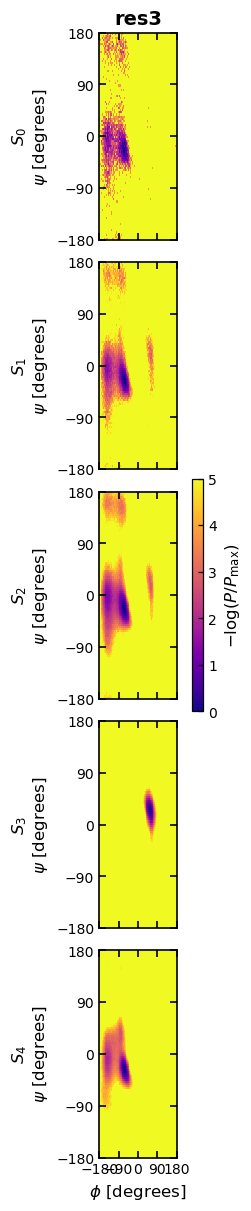

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# ------------------------------------------------------------
# Load dihedrals
# ------------------------------------------------------------
dihedral_timeseries = np.loadtxt(
    data_folder + "hp35.dihs",
    delimiter=" ",
    dtype=float
)

phis_timeseries = dihedral_timeseries[:, 0::2]
psis_timeseries = dihedral_timeseries[:, 1::2]


# ------------------------------------------------------------
# Define macrostates automatically
# ------------------------------------------------------------
model_name = "tica_dihedrals"

macrostate_traj = np.asarray(
    hard_assignments_timeseries_dict[model_name],
    dtype=int
)

if macrostate_traj.shape[0] != dihedral_timeseries.shape[0]:
    raise ValueError(
        "The macrostate assignment trajectory and dihedral trajectory "
        "must contain the same number of frames."
    )

state_labels = np.unique(macrostate_traj)

macrostate_frames = {
    state: np.flatnonzero(macrostate_traj == state)
    for state in state_labels
}


# ------------------------------------------------------------
# Ramachandran free-energy helper
# ------------------------------------------------------------
def ramachandran_free_energy(
    phi,
    psi,
    bins=100,
    pseudocount=1e-12
):
    """
    Compute a relative Ramachandran free-energy surface:

        F(phi, psi) = -log[P(phi, psi) / Pmax]

    Parameters
    ----------
    phi, psi : array-like
        Dihedral angles in degrees.

    bins : int
        Number of histogram bins along each dimension.

    pseudocount : float
        Small value added to avoid log(0).

    Returns
    -------
    phi_centers, psi_centers, F
    """
    phi = np.asarray(phi, dtype=float)
    psi = np.asarray(psi, dtype=float)

    valid = np.isfinite(phi) & np.isfinite(psi)
    phi = phi[valid]
    psi = psi[valid]

    if phi.size == 0:
        raise ValueError("No valid phi/psi samples were provided.")

    H, phi_edges, psi_edges = np.histogram2d(
        phi,
        psi,
        bins=bins,
        range=[[-180, 180], [-180, 180]],
        density=False
    )

    P = H / H.sum()
    P = P + pseudocount

    F = -np.log(P / P.max())
    F = F.T

    phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    psi_centers = 0.5 * (psi_edges[:-1] + psi_edges[1:])

    return phi_centers, psi_centers, F


# ------------------------------------------------------------
# Validate residue input
# ------------------------------------------------------------
if len(residue_names) != len(residue_cols):
    raise ValueError(
        "residue_names and residue_cols must have the same length."
    )

n_rows = len(state_labels)
n_cols = len(residue_cols)

if n_rows == 0:
    raise ValueError("No states found in the assignment trajectory.")

if n_cols == 0:
    raise ValueError("No residue columns were provided.")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axs = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(2.4 * n_cols, 2.4 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False
)

vmax = 5.0
norm = Normalize(vmin=0, vmax=vmax)

last_im = None

for row, state in enumerate(state_labels):

    frames = macrostate_frames[state]

    if frames.size == 0:
        continue

    for col, (res_name, res_col) in enumerate(
        zip(residue_names, residue_cols)
    ):
        ax = axs[row, col]

        if res_col < 0 or res_col >= phis_timeseries.shape[1]:
            raise IndexError(
                f"Residue column {res_col} is outside the available "
                f"range 0-{phis_timeseries.shape[1] - 1}."
            )

        phi = phis_timeseries[frames, res_col]
        psi = psis_timeseries[frames, res_col]

        x, y, F = ramachandran_free_energy(
            phi,
            psi,
            bins=100
        )

        F_plot = np.clip(F, 0, vmax)

        last_im = ax.pcolormesh(
            x,
            y,
            F_plot,
            shading="auto",
            cmap="plasma",
            norm=norm
        )

        # Residue titles only on the first row
        if row == 0:
            ax.set_title(
                res_name,
                fontsize=14,
                fontweight="bold"
            )

        # State labels only on the first column
        if col == 0:
            ax.set_ylabel(
                rf"$S_{{{state}}}$" + "\n" + r"$\psi$ [degrees]",
                fontsize=12
            )

        # Phi label only on the final row
        if row == n_rows - 1:
            ax.set_xlabel(
                r"$\phi$ [degrees]",
                fontsize=12
            )

        ax.set_xlim(-180, 180)
        ax.set_ylim(-180, 180)

        ax.set_xticks([-180, -90, 0, 90, 180])
        ax.set_yticks([-180, -90, 0, 90, 180])

        ax.tick_params(
            direction="in",
            length=5,
            width=1.2,
            top=True,
            right=True
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.2)


# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------
if last_im is not None:
    cbar = fig.colorbar(
        last_im,
        ax=axs,
        location="right",
        shrink=0.85,
        pad=0.02
    )

    cbar.set_label(
        r"$-\log(P/P_{\max})$",
        fontsize=12
    )

    cbar.set_ticks(np.arange(0, vmax + 1, 1))


fig.savefig(
    "../output_figures/dihedrals_ramachandran_macrostate_comparison.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/dihedrals_ramachandran_macrostate_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

S0 and S1 change for the dihedral distribution of residues 20 and 21. 

These are details of loop 2

Ok but does it have any meaning?

In S0, the second loop is together with helix 2

In S1 and S2, it forms properly as loop.




Hence, reflecting different aspects of the structural dynamics, contacts and dihedrals result in different collective variables and metastable states, eventually leading to MSMs with different time scales and pathways.

## Cored trajectory

In [87]:
import numpy as np


def core_discrete_trajectory(
    hard,
    min_core_frames,
    allowed_states=None
):
    """
    Apply temporal coring to a discrete trajectory with any number of states.

    A transition from the current state to a candidate state is accepted only
    if the trajectory remains continuously in that candidate state for at
    least `min_core_frames`.

    Short excursions that do not satisfy this condition are reassigned to the
    previously accepted core state.

    Parameters
    ----------
    hard : array-like of shape (n_frames,)
        Discrete trajectory containing integer state labels.

    min_core_frames : int
        Minimum number of consecutive frames required to accept a transition
        into a new state.

    allowed_states : array-like, optional
        Explicit set of valid state labels. When None, all integer labels
        present in `hard` are accepted.

    Returns
    -------
    cored : np.ndarray of shape (n_frames,)
        Temporally cored trajectory.

    Notes
    -----
    When a transition is accepted, the new state is assigned retroactively
    from the first frame of the qualifying consecutive run.
    """
    hard = np.asarray(hard)

    if hard.ndim != 1:
        raise ValueError("hard must be a one-dimensional trajectory.")

    if hard.size == 0:
        return hard.copy()

    if not np.issubdtype(hard.dtype, np.integer):
        if np.all(np.isfinite(hard)) and np.all(hard == np.floor(hard)):
            hard = hard.astype(int)
        else:
            raise ValueError("hard must contain integer state labels.")
    else:
        hard = hard.astype(int, copy=False)

    if allowed_states is not None:
        allowed_states = np.asarray(allowed_states, dtype=int)

        invalid = np.setdiff1d(np.unique(hard), allowed_states)

        if invalid.size > 0:
            raise ValueError(
                f"hard contains invalid state labels: {invalid.tolist()}"
            )

    min_core_frames = int(min_core_frames)

    if min_core_frames < 1:
        raise ValueError("min_core_frames must be at least 1.")

    cored = np.empty_like(hard)

    current_state = hard[0]
    cored[0] = current_state

    candidate_state = None
    candidate_start = None
    candidate_length = 0

    for i in range(1, hard.size):
        observed_state = hard[i]

        if observed_state == current_state:
            # The trajectory returned to the current accepted core before
            # another state persisted long enough.
            candidate_state = None
            candidate_start = None
            candidate_length = 0

            cored[i] = current_state
            continue

        if observed_state == candidate_state:
            candidate_length += 1
        else:
            # Start testing a new candidate state. This also handles direct
            # switches between different unaccepted candidate states.
            candidate_state = observed_state
            candidate_start = i
            candidate_length = 1

        if candidate_length >= min_core_frames:
            # Accept the transition and assign it retroactively from the
            # beginning of the qualifying run.
            current_state = candidate_state
            cored[candidate_start:i + 1] = current_state

            candidate_state = None
            candidate_start = None
            candidate_length = 0
        else:
            cored[i] = current_state

    return cored


min_core_markov_steps = 1

min_core_mus = (
    min_core_markov_steps
    * MSM_LAG_NS
    / 1000
)

min_core_frames = max(
    1,
    int(np.ceil(min_core_mus / time_step_micros))
)

print(f"Minimum core time: {min_core_mus:.3f} µs")
print("Minimum core frames:", min_core_frames)


cored_assignments_timeseries_dict = {}

for name in trajectories_labels:
    hard = np.asarray(
        hard_assignments_timeseries_dict[name],
        dtype=int
    )

    cored_assignments_timeseries_dict[name] = (
        core_discrete_trajectory(
            hard,
            min_core_frames=min_core_frames
        )
    )

name = trajectories_labels[0]

tmin_mus = 0
tmax_mus = 50

frame_min = max(
    0,
    int(np.floor(tmin_mus / time_step_micros))
)

frame_max = min(
    len(hard_assignments_timeseries_dict[name]),
    int(np.ceil(tmax_mus / time_step_micros))
)

time_mus = (
    np.arange(frame_min, frame_max)
    * time_step_micros
)

raw = hard_assignments_timeseries_dict[name][frame_min:frame_max]
cored = cored_assignments_timeseries_dict[name][frame_min:frame_max]

Minimum core time: 0.050 µs
Minimum core frames: 251


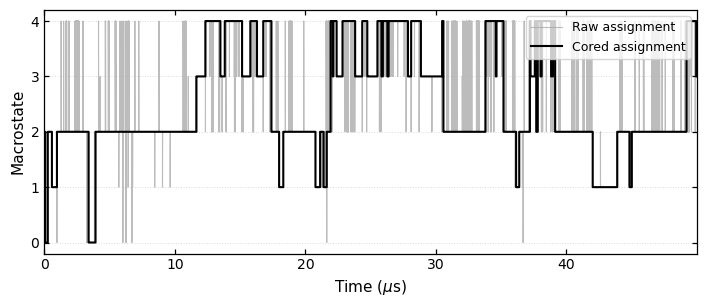

In [88]:
# Small offset used only for visualization
raw_offset = 0.0

fig, ax = plt.subplots(figsize=(7.2, 3.2))

# Raw PCCA trajectory: secondary/background information
ax.step(
    time_mus,
    raw + raw_offset,
    where="post",
    color="0.65",
    linewidth=0.8,
    alpha=0.75,
    label="Raw assignment",
    zorder=1
)

# Cored trajectory: primary information
ax.step(
    time_mus,
    cored,
    where="post",
    color="black",
    linewidth=1.5,
    label="Cored assignment",
    zorder=2
)

# Axis formatting
ax.set_xlabel(r"Time ($\mu$s)", fontsize=11)
ax.set_ylabel("Macrostate", fontsize=11)

#ax.set_yticks([0, 1, 2])
#ax.set_yticklabels(["0", "1", "2"])
#ax.set_ylim(-0.25, 2.25)

ax.set_xlim(time_mus[0], time_mus[-1])

# Minimal grid
ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.7,
    alpha=0.45,
    zorder=0
)

# Clean frame
#ax.spines["top"].set_visible(False)
#ax.spines["right"].set_visible(False)

ax.tick_params(
    #axis="both",
    which="major",
    labelsize=10,
    #direction="out"
)

ax.legend(
    frameon=True,
    fontsize=9,
    loc="upper right",
    handlelength=2.5
)

fig.tight_layout()

# Report-quality vector output
fig.savefig(
    "../output_figures/tica_dihedrals_3_pcca_coring_trajectory.pdf",
    bbox_inches="tight"
)

# Optional high-resolution raster output
#fig.savefig(
#   "../figures/tica_dihedrals_3_pcca_coring_trajectory.pdf",
#    dpi=300,
#   bbox_inches="tight"
#)

plt.show()

In [89]:
macrostate = 6

# Frames assigned to macrostate 0
macro0_frames = np.flatnonzero(cored == macrostate)

all_permanence_times = []
all_permanence_frames = []

if macro0_frames.size > 0:

    # A gap larger than one frame marks the beginning of a new visit
    split_points = np.where(np.diff(macro0_frames) > 1)[0] + 1

    # Separate contiguous visits to macrostate 0
    macro0_visits = np.split(macro0_frames, split_points)

    for visit_index, visit_frames in enumerate(macro0_visits, start=1):

        lifetime_frames = len(visit_frames)
        lifetime_mus = lifetime_frames * time_step_micros

        all_permanence_frames.append(lifetime_frames)
        all_permanence_times.append(lifetime_mus)

        print(
            f"Macrostate 0 visit {visit_index}: "
            f"{lifetime_mus:.3f} µs "
            f"({lifetime_frames} frames; "
            f"frames {visit_frames[0]}–{visit_frames[-1]})"
        )

else:
    print("Macrostate 0 is never visited.")

all_permanence_frames = np.asarray(all_permanence_frames, dtype=int)
all_permanence_times = np.asarray(all_permanence_times, dtype=float)

if all_permanence_times.size > 0:
    print()
    print(f"Number of visits: {len(all_permanence_times)}")
    print(
        f"Mean permanence time: "
        f"{all_permanence_times.mean():.3f} µs"
    )
    print(
        f"Median permanence time: "
        f"{np.median(all_permanence_times):.3f} µs"
    )
    print(
        f"Maximum permanence time: "
        f"{all_permanence_times.max():.3f} µs"
    )

Macrostate 0 is never visited.


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

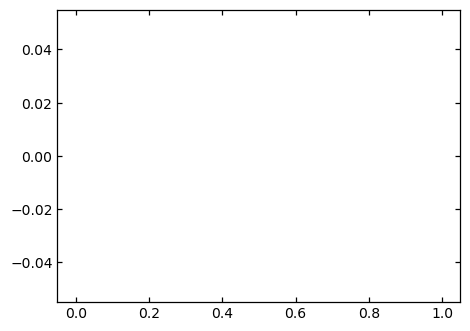

In [90]:
fig, ax = plt.subplots(figsize=(5.2, 3.8))


ax.hist(all_permanence_times)

In [91]:
#Longest visit at frames:
#1116291–1122716

time_start = 1116291 * time_step_micros
time_end = 1122716 * time_step_micros
print(f"Longest visit: {time_start:.3f}–{time_end:.3f} µs")

Longest visit: 223.106–224.390 µs
